# Example: Find square roots by iteration

The so-called *Heron's method* for finding the square root of a number involves starting with a guess, and iteratively improving this guess. Iterations end when the difference between two successive guesses is smaller than a threshold value.

The method is expressed mathematically as follows: Suppose we want the square root of the number $N$. We start with an initial guess $x_0$. Based on this, the next guess $x_1$ is:
$$x_1 = \frac{1}{2}\left(x_0 + \frac{N}{x_0}\right)$$
From this estimate, we generate a better estimate $x_2$:
$$x_2 = \frac{1}{2}\left(x_1 + \frac{N}{x_1}\right)$$
and so on.

Generally, if our estimate is $x_n$, the next estimate will be:
$$x_{n+1} = \frac{1}{2}\left(x_n + \frac{N}{x_n}\right)$$

For example, suppose we want to find the square root of 2, starting with an initial guess of 1. Then, following the steps, the algorithm gives:
$$\begin{eqnarray}
x_1 &=& \frac{1}{2}\left(1 + \frac{2}{1}\right) = \frac{3}{2} = 1.5\\
x_2 &=& \frac{1}{2}\left(3/2 + \frac{2}{3/2}\right) = \frac{17}{12} = 1.4166666666666665\\
x_3 &=& \frac{1}{2}\left(x_2 + \frac{2}{x_2}\right) = \frac{577}{408} = 1.4142156862745097\\
x_4 &=& \frac{1}{2}\left(x_3 + \frac{2}{x_3}\right) = \frac{665857}{470832} = 1.4142135623746899\\
x_5 &=& \frac{1}{2}\left(x_4 + \frac{2}{x_4}\right) = \frac{886731088897}{627013566048} = 1.414213562373095\\
x_6 &=& \frac{1}{2}\left(x_5 + \frac{2}{x_5}\right) = \frac{1572584048032918633353217}{1111984844349868137938112} = 1.414213562373095\\
\end{eqnarray}$$

We can stop after six iterations, as the difference between the previous and the current guesses is very small.

Our goals:

1. Set up a program that executes this algorithm.
2. Try it with different inputs and different initial guesses.
3. Use a plot to see how fast the results converge.
4. Use rational numbers for the input number and initial guess, and print the successive guesses as fractions.
5. Create a function `square_root` that encapsulates this algorithm.

We work out this problem in the classroom.

As a first step, we start with an initial guess and generate 10 iterations.

Create a small function that generates a new guess from a given guess.

In [1]:
def improved_guess(x, N):
    return 0.5*(x + N/x)

In [2]:
N = 2 # find the square root of N
guess = 1 # initial guess

for i in range(10):
    guess = improved_guess(guess, N)
    print(f"Iteration {i}, guess = {guess}, error = {abs(guess**2 - N)}")

Iteration 0, guess = 1.5, error = 0.25
Iteration 1, guess = 1.4166666666666665, error = 0.006944444444444198
Iteration 2, guess = 1.4142156862745097, error = 6.007304882427178e-06
Iteration 3, guess = 1.4142135623746899, error = 4.510614104447086e-12
Iteration 4, guess = 1.414213562373095, error = 4.440892098500626e-16
Iteration 5, guess = 1.414213562373095, error = 4.440892098500626e-16
Iteration 6, guess = 1.414213562373095, error = 4.440892098500626e-16
Iteration 7, guess = 1.414213562373095, error = 4.440892098500626e-16
Iteration 8, guess = 1.414213562373095, error = 4.440892098500626e-16
Iteration 9, guess = 1.414213562373095, error = 4.440892098500626e-16


We see that after iteration 4, the error reaches the machine precision and does not change anymore.

Let's add a stopping condition: Stop when the next guess is not significantly different from the current guess.



In [3]:
N = 2 # find the square root of N
guess = 1 # initial guess
tolerance = 1e-10
diff = 2*tolerance # just any initial value that is large so that the itartion can start
while diff>tolerance: # continue as long as the difference is greater than the tolerance level.
    new_guess = improved_guess(guess, N)
    diff = abs(new_guess - guess)
    guess = new_guess
    print(f"guess = {guess}, error = {abs(guess**2 - N)}")

guess = 1.5, error = 0.25
guess = 1.4166666666666665, error = 0.006944444444444198
guess = 1.4142156862745097, error = 6.007304882427178e-06
guess = 1.4142135623746899, error = 4.510614104447086e-12
guess = 1.414213562373095, error = 4.440892098500626e-16


Let's check the sensitivity to initial guess by giving a wildly off initial guess.

In [4]:
N = 2 # find the square root of N
guess = 100 # initial guess
tolerance = 1e-10
diff = 2*tolerance
while diff>tolerance:
    new_guess = improved_guess(guess, N)
    diff = abs(new_guess - guess)
    guess = new_guess
    print(f"guess = {guess}, error = {abs(guess**2 - N)}")

guess = 50.01, error = 2499.0000999999997
guess = 25.024996000799838, error = 624.2504248400479
guess = 12.552458046745903, error = 155.56420301531597
guess = 6.35589469493114, error = 38.39739737305381
guess = 3.335281609280434, error = 9.124103413204281
guess = 1.967465562231149, error = 1.8709207385655313
guess = 1.4920008896897232, error = 0.22606665483492572
guess = 1.4162413320389438, error = 0.005739510575441642
guess = 1.4142150140500531, error = 4.105964591882838e-06
guess = 1.41421356237384, error = 2.107203300738547e-12
guess = 1.414213562373095, error = 4.440892098500626e-16


Now it takes 11 iterations to find get a solution.

Now let's give larger numbers:

In [5]:
N = 1238476517 # find the square root of N
guess = 10000 # initial guess
tolerance = 1e-10
diff = 2*tolerance
while diff>tolerance:
    new_guess = improved_guess(guess, N)
    diff = abs(new_guess - guess)
    guess = new_guess
    print(f"guess = {guess}, error = {abs(guess**2 - N)}")

guess = 66923.82585, error = 3240321949.401128
guess = 42714.79484911372, error = 586077182.0018721
guess = 35854.441380577366, error = 47064449.713258505
guess = 35198.114745702595, error = 430764.65164637566
guess = 35191.995601896764, error = 37.44392108917236
guess = 35191.99506990191, error = 2.384185791015625e-07
guess = 35191.99506990191, error = 2.384185791015625e-07


Even with large numbers, only a few iterations are sufficient.

Let's plot the intermediate guesses to visualize how quickly the algorithm converges:

In [6]:
import matplotlib.pyplot as plt

In [7]:
N = 2 # find the square root of N
guess = 10000 # initial guess
tolerance = 1e-10
diff = 2*tolerance
guess_list = []
while diff>tolerance:
    new_guess = improved_guess(guess, N)
    diff = abs(new_guess - guess)
    guess = new_guess
    guess_list.append(guess)

guess_list

[5000.0001,
 2500.000249999996,
 1250.000524999958,
 625.001062499643,
 312.5021312471015,
 156.25426560172693,
 78.13353262614919,
 39.0795649152418,
 19.565371278841628,
 9.833796348527644,
 5.018588301307151,
 2.708553372562561,
 1.7234774597014848,
 1.441960997552001,
 1.4144805322010983,
 1.4142135875671107,
 1.4142135623730954,
 1.414213562373095]

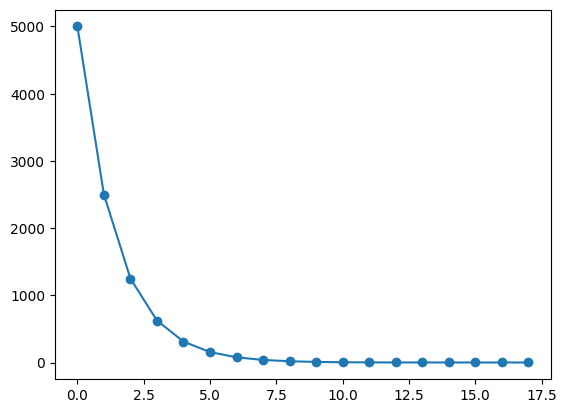

In [8]:
plt.plot(guess_list, "o-")

Finally, let's wrap up the algorithm in a function so that we can reuse it when necessary.

We make the initial guess and tolerance as optional arguments. If not provided, we take the half of the number as the initial guess.

In [9]:
def square_root(N, initial_guess=None, tolerance=1e-10):
    if initial_guess is None:
        initial_guess = N/2
    diff = 2*tolerance
    guess = initial_guess
    while diff>tolerance:
        new_guess = 0.5*(guess + N/guess)
        diff = abs(new_guess - guess)
        guess = new_guess
    return guess

In [10]:
square_root(10)

3.162277660168379

In [11]:
square_root(10, initial_guess=7)

3.162277660168379

In [12]:
square_root(10, initial_guess=7, tolerance=1e-3)

3.1622776601685647